# Практична робота 3.5
## Аналіз набору даних з Kaggle

**Мета роботи:** навчитися завантажувати, очищати, трансформувати та аналізувати
реальні набори даних з платформи Kaggle, використовуючи методи трансформації
та декомпозиції даних для моделювання.

### 1. Вибір набору даних з Kaggle

Обрано набір даних «Diamonds» із категорії бізнес — характеристики та ціни
53 940 діамантів.

Файл: `../data/diamonds.csv` — 53 940 записів, 10 стовпців.

| Стовпець | Опис |
|---|---|
| `carat` | вага діаманта в каратах |
| `cut` | якість огранки (категоріальна) |
| `color` | колір від J до D (категоріальна) |
| `clarity` | чистота від I1 до IF (категоріальна) |
| `depth` | відносна глибина, % |
| `table` | ширина верхнього майданчика, % |
| `price` | ціна в доларах США |
| `x`, `y`, `z` | довжина, ширина, висота в мм |

### 2. Завантаження та попередній перегляд даних

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Завантаження даних
df = pd.read_csv('../data/diamonds.csv')

# Перегляд перших рядків
print(df.head())

   carat      cut color clarity  depth  table  price     x     y     z
0   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75


In [2]:
# Огляд інформації про набір даних
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  str    
 2   color    53940 non-null  str    
 3   clarity  53940 non-null  str    
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), str(3)
memory usage: 4.1 MB
None


In [3]:
print('Кількість рядків і стовпців:', df.shape)

Кількість рядків і стовпців: (53940, 10)


### 3. Очищення даних

In [4]:
# Перевірка на пропущені значення
print(df.isnull().sum())

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64


In [5]:
# Формально пропусків немає, але серед розмірів трапляються нулі,
# а діамант не може мати нульовий розмір - це прихований пропуск.
print('Рядків із нульовим розміром:', ((df[['x', 'y', 'z']] == 0).any(axis=1)).sum())

df[['x', 'y', 'z']] = df[['x', 'y', 'z']].replace(0, np.nan)

# Заповнення пропущених значень медіаною
df['x'] = df['x'].fillna(df['x'].median())
df['y'] = df['y'].fillna(df['y'].median())
df['z'] = df['z'].fillna(df['z'].median())

print('Пропущених значень залишилось:', df.isnull().sum().sum())

Рядків із нульовим розміром: 20
Пропущених значень залишилось: 0


In [6]:
# Видалення дублікатів
print('Рядків до видалення дублікатів:', len(df))
df = df.drop_duplicates().reset_index(drop=True)
print('Рядків після видалення:       ', len(df))

Рядків до видалення дублікатів: 53940
Рядків після видалення:        53794


In [7]:
# Перетворення категоріальних змінних на числові
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

df['cut_code'] = pd.Categorical(df['cut'], categories=cut_order, ordered=True).codes
df['color_code'] = pd.Categorical(df['color'], categories=color_order, ordered=True).codes
df['clarity_code'] = pd.Categorical(df['clarity'], categories=clarity_order, ordered=True).codes

print(df[['cut', 'cut_code', 'color', 'color_code', 'clarity', 'clarity_code']].head())

       cut  cut_code color  color_code clarity  clarity_code
0    Ideal         4     E           5     SI2             1
1  Premium         3     E           5     SI1             2
2     Good         1     E           5     VS1             4
3  Premium         3     I           1     VS2             3
4     Good         1     J           0     SI2             1


### 4. Трансформація даних

- нормалізація кількісних змінних методом MinMax;
- One-Hot Encoding для категоріальної змінної `cut`.

In [8]:
from sklearn.preprocessing import MinMaxScaler

# Нормалізація числових змінних
scaler = MinMaxScaler()
df[['carat_scaled', 'price_scaled']] = scaler.fit_transform(df[['carat', 'price']])

print(df[['carat', 'carat_scaled', 'price', 'price_scaled']].head())

   carat  carat_scaled  price  price_scaled
0   0.23      0.006237    326      0.000000
1   0.21      0.002079    326      0.000000
2   0.23      0.006237    327      0.000054
3   0.29      0.018711    334      0.000433
4   0.31      0.022869    335      0.000487


In [9]:
# One-Hot Encoding для якості огранки
df_transformed = pd.get_dummies(df, columns=['cut'], prefix='cut', dtype=int)

cut_cols = [col for col in df_transformed.columns if col.startswith('cut_') and col != 'cut_code']
print('Створено бінарних ознак:', len(cut_cols))
print(df_transformed[cut_cols].head())

Створено бінарних ознак: 5
   cut_Fair  cut_Good  cut_Ideal  cut_Premium  cut_Very Good
0         0         0          1            0              0
1         0         0          0            1              0
2         0         1          0            0              0
3         0         0          0            1              0
4         0         1          0            0              0


### 5. Декомпозиція набору даних

In [10]:
from sklearn.model_selection import train_test_split

# Поділ на навчальну та тестову вибірки (80% / 20%)
train_set, test_set = train_test_split(df_transformed, test_size=0.2, random_state=42)

print('Навчальна вибірка:', train_set.shape)
print('Тестова вибірка:  ', test_set.shape)

Навчальна вибірка: (43035, 19)
Тестова вибірка:   (10759, 19)


In [11]:
# Кореляційна матриця для кількісних змінних
numbers = df[['carat', 'price', 'depth', 'table', 'cut_code', 'color_code', 'clarity_code']]
correlation_matrix = numbers.corr()

print(correlation_matrix.round(3))

              carat  price  depth  table  cut_code  color_code  clarity_code
carat         1.000  0.922  0.028  0.181    -0.133      -0.291        -0.352
price         0.922  1.000 -0.011  0.127    -0.052      -0.172        -0.146
depth         0.028 -0.011  1.000 -0.298    -0.217      -0.048        -0.067
table         0.181  0.127 -0.298  1.000    -0.434      -0.026        -0.160
cut_code     -0.133 -0.052 -0.217 -0.434     1.000       0.020         0.188
color_code   -0.291 -0.172 -0.048 -0.026     0.020       1.000        -0.026
clarity_code -0.352 -0.146 -0.067 -0.160     0.188      -0.026         1.000


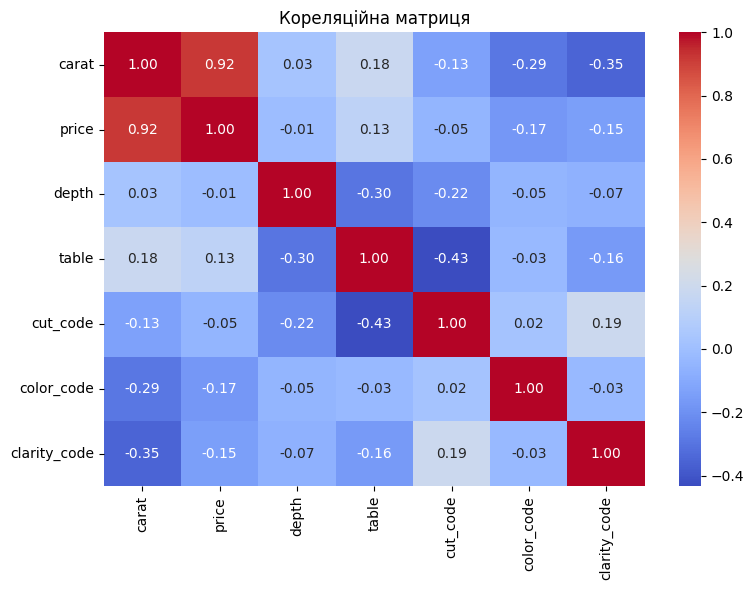

In [12]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Кореляційна матриця')
plt.tight_layout()
plt.show()

### 6. Описова статистика та візуалізація

In [13]:
# Описова статистика
print(df[['carat', 'price', 'depth', 'table']].describe().round(2))

          carat     price     depth     table
count  53794.00  53794.00  53794.00  53794.00
mean       0.80   3933.07     61.75     57.46
std        0.47   3988.11      1.43      2.23
min        0.20    326.00     43.00     43.00
25%        0.40    951.00     61.00     56.00
50%        0.70   2401.00     61.80     57.00
75%        1.04   5326.75     62.50     59.00
max        5.01  18823.00     79.00     95.00


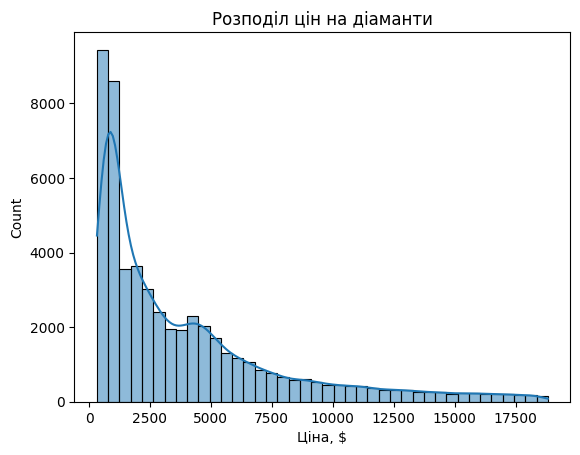

In [14]:
# Гістограма для кількісної змінної
sns.histplot(df['price'], bins=40, kde=True)
plt.title('Розподіл цін на діаманти')
plt.xlabel('Ціна, $')
plt.show()

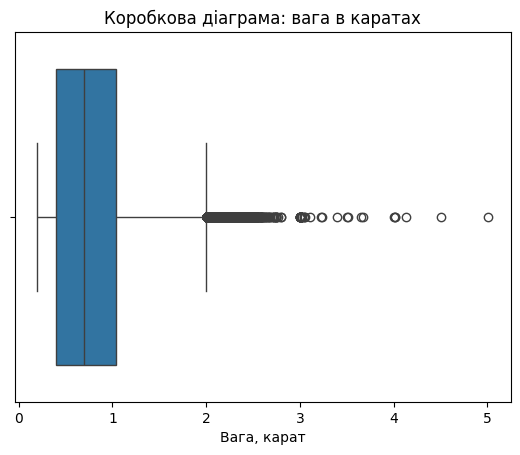

In [15]:
# Коробкова діаграма
sns.boxplot(x=df['carat'])
plt.title('Коробкова діаграма: вага в каратах')
plt.xlabel('Вага, карат')
plt.show()

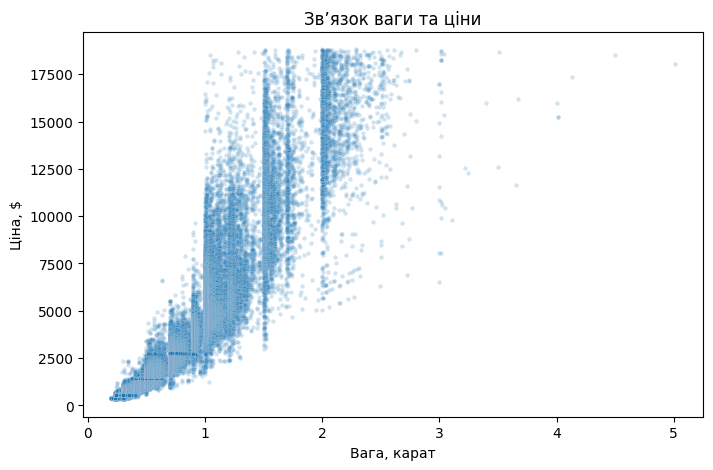

In [16]:
# Діаграма розсіювання
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['carat'], y=df['price'], alpha=0.2, s=10)
plt.title('Звʼязок ваги та ціни')
plt.xlabel('Вага, карат')
plt.ylabel('Ціна, $')
plt.show()

### 7. Побудова моделі

Будуємо лінійну регресію: прогнозуємо ціну діаманта (`price`)
за вагою, розмірами та оцінками якості.

In [17]:
from sklearn.linear_model import LinearRegression

features = ['carat', 'depth', 'table', 'x', 'y', 'z',
            'cut_code', 'color_code', 'clarity_code']
target = 'price'

# Навчання моделі
model = LinearRegression()
model.fit(train_set[features], train_set[target])

# Прогноз на тестовій вибірці
predictions = model.predict(test_set[features])
print(predictions[:10].round(0))

[1441. 4059. 2329. 1764. 6061.  247. -156. 1640. 1508. 4695.]


In [18]:
from sklearn.metrics import r2_score, mean_absolute_error

r2 = r2_score(test_set[target], predictions)
mae = mean_absolute_error(test_set[target], predictions)

print('R2 =', round(r2, 3))
print('Середня абсолютна помилка =', round(mae, 1), '$')
print()
print('Коефіцієнти моделі:')
print(pd.Series(model.coef_, index=features).round(1))

R2 = 0.905
Середня абсолютна помилка = 785.5 $

Коефіцієнти моделі:
carat           10974.8
depth             -39.5
table             -27.6
x                -546.8
y                  98.2
z                -818.3
cut_code          119.1
color_code        322.5
clarity_code      502.1
dtype: float64


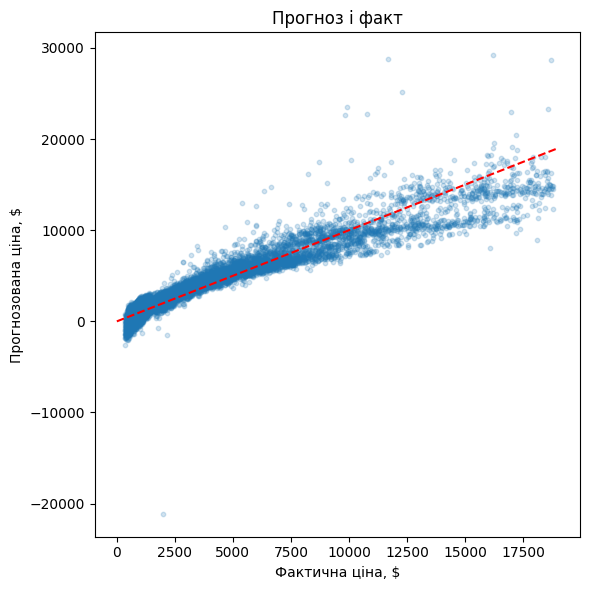

In [19]:
plt.figure(figsize=(6, 6))
plt.scatter(test_set[target], predictions, alpha=0.2, s=10)
plt.plot([0, 19000], [0, 19000], 'r--')
plt.xlabel('Фактична ціна, $')
plt.ylabel('Прогнозована ціна, $')
plt.title('Прогноз і факт')
plt.tight_layout()
plt.show()

### 8. Звітування. Висновки

**Опис набору даних.** Використано набір «Diamonds» з Kaggle — 53 940 записів
про продані діаманти: вага, три оцінки якості, геометричні розміри та ціна.

**Очищення та трансформація.** Функція `isnull()` показала нуль пропусків,
але у 20 записах розміри `x`, `y` або `z` дорівнювали нулю — фізично неможливе
значення, тобто прихований пропуск. Такі нулі замінено на `NaN` і заповнено
медіаною. Видалено 146 повних дублікатів, залишилось 53 794 записи.

Категоріальні змінні перетворено на числові двома способами:
через упорядковане кодування (`cut_code`, `color_code`, `clarity_code`)
та One-Hot Encoding для огранки. Числові змінні `carat` і `price`
нормалізовано методом MinMax.

**Аналіз кореляції.** Найсильніший зв'язок — між вагою та ціною: **0.92**.
Оцінки якості корелюють із ціною слабко й навіть від'ємно
(`color_code` -0.17, `clarity_code` -0.15, `cut_code` -0.05). Причина не в тому,
що якість не важлива, а в тому, що кращі за кольором і чистотою камені
здебільшого дрібніші — вага переважує все інше.

**Візуалізація.** Гістограма цін показує сильну правосторонню асиметрію:
більшість діамантів коштують до 5 000 $, але є поодинокі камені
майже на 19 000 $. Коробкова діаграма ваги демонструє багато викидів
у бік важких каменів. Діаграма розсіювання виявляє головну особливість даних:
звʼязок ваги та ціни **нелінійний** — крива загинається вгору, бо великі камені
зустрічаються рідше й дорожчають швидше, ніж зростає їхня вага.

**Результат моделі.** Лінійна регресія на дев'яти ознаках дала
**R² = 0.905** і середню абсолютну помилку **786 $**. Модель пояснює
понад 90 % розкиду цін — це високий результат.

Помітна межа точності видно на графіку «прогноз і факт»: для дешевих каменів
модель іноді видає **від'ємну ціну**, а для найдорожчих систематично занижує
прогноз. Обидві похибки мають одну причину — модель лінійна, а справжня
залежність ціни від ваги опукла.

**Висновок.** У роботі виконано повний цикл роботи з реальними даними:
завантаження, очищення, трансформація, декомпозиція, аналіз та моделювання.
Ціну діаманта визначає передусім вага. Щоб покращити прогноз, варто
прологарифмувати ціну й вагу — це випрямить залежність — або перейти
до нелінійних моделей.